In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipas.transport import (
    ghosh_material_parameters, makhov_material_parameters,
    ghosh_profile, makhov_profile, multilayer_implantation_profile)
from scipas.model import Material, Layer, Sample

In [2]:
# ── Adapt to your sample ──────────────────────────────────────────────────────
sample_width   = 10_000 # Si substrate (effectively semi-infinite) [nm]
L                = 150.0  # positron diffusion length in Cu [nm]
absorption_length = 1.0    # surface absorption length [nm]
D                 = 1.0    # normalised diffusion coefficient (only L = sqrt(D/λ) matters)
# ─────────────────────────────────────────────────────────────────────────────

cu_layer = Layer(width=sample_width, material=Material(diffusion=D, mobility=0, bulk_annihilation_rate=D / L**2))
sample = Sample(layers=[cu_layer], absorption_length=absorption_length)

In [3]:
ghosh_params  = ghosh_material_parameters()

# Cu: row 9
Cu_ghosh   = ghosh_params.iloc[9]
print('Cu Ghosh params:')
print(Cu_ghosh[['density','Z','m','l']].to_string())

Cu Ghosh params:
density     8.96
Z           29.0
m           3.02
l          0.374


In [4]:
depth  = np.linspace(0, sample.sample_length(), 10_000)   # [nm]
widths    = [sample_width]
densities = [Cu_ghosh['density']]

/tmp/ipykernel_143439/2437500648.py:16: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(0, depth[-1] * 0.35)


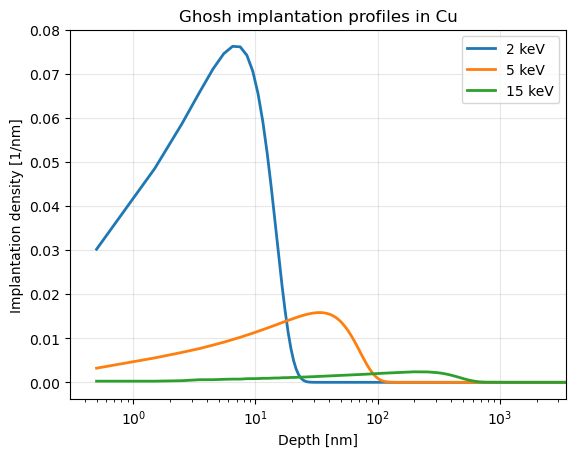

In [5]:
# ── Adapt energy range ────────────────────────────────────────────────────────
energies_keV = [2, 5, 15]   # beam energies to compare [keV]
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots()
for e in energies_keV:
    prof = multilayer_implantation_profile(
        positron_energy=e, depth_vector=depth,
        widths=widths, materials_parameters=[Cu_ghosh],
        densities=densities, implantation_profile_function=ghosh_profile)
    ax.plot(prof.coords['x'].values, prof.values, lw=2, label=f'{e} keV')
ax.set_xscale('log')
ax.set_xlabel('Depth [nm]')
ax.set_ylabel('Implantation density [1/nm]')
ax.set_title(f'Ghosh implantation profiles in Cu')
ax.set_xlim(0, depth[-1] * 0.35)
ax.grid(True, alpha=0.3)
plt.legend()
plt.show()